In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# ── Load clean data ───────────────────────────────────────────
df = pd.read_csv("../data/oxidative_stress_data_clean.csv")

markers     = ["MDA", "GSH", "GpX", "GRD", "SOD"]
group_order = ["Normal Control", "Atherosclerotic Control",
               "Low-Dose NAC",  "High-Dose NAC", "NAC Treatment"]
df["Group"] = pd.Categorical(df["Group"], 
                              categories=group_order, ordered=True)

colors       = ["#4878CF","#D65F5F","#F0A500","#6ACC65","#845EC2"]
units        = {"MDA":"nmol/dL","GSH":"µmol/L",
                "GpX":"U/L","GRD":"U/L","SOD":"U/L"}
panel_labels = ["A","B","C","D","E"]

# ── Rebuild CLD letters ───────────────────────────────────────
def get_cld_letters(marker):
    tukey = pairwise_tukeyhsd(endog=df[marker],
                               groups=df["Group"], alpha=0.05)
    G = nx.Graph()
    G.add_nodes_from(group_order)
    for row in tukey.summary().data[1:]:
        g1, g2, _, p_adj, _, _, reject = row
        if not reject:
            G.add_edge(g1, g2)
    cliques = list(nx.find_cliques(G))
    gm = df.groupby("Group")[marker].mean()
    cliques.sort(key=lambda c: -max(gm[g] for g in c))
    letters = {g: "" for g in group_order}
    for i, clique in enumerate(cliques):
        letter = chr(ord('a') + i)
        for g in clique:
            letters[g] += letter
    for g in letters:
        letters[g] = "".join(sorted(letters[g]))
    return letters

all_letters = {m: get_cld_letters(m) for m in markers}

palette = dict(zip(group_order, colors))
print("✅ Setup complete — all variables ready")

✅ Setup complete — all variables ready


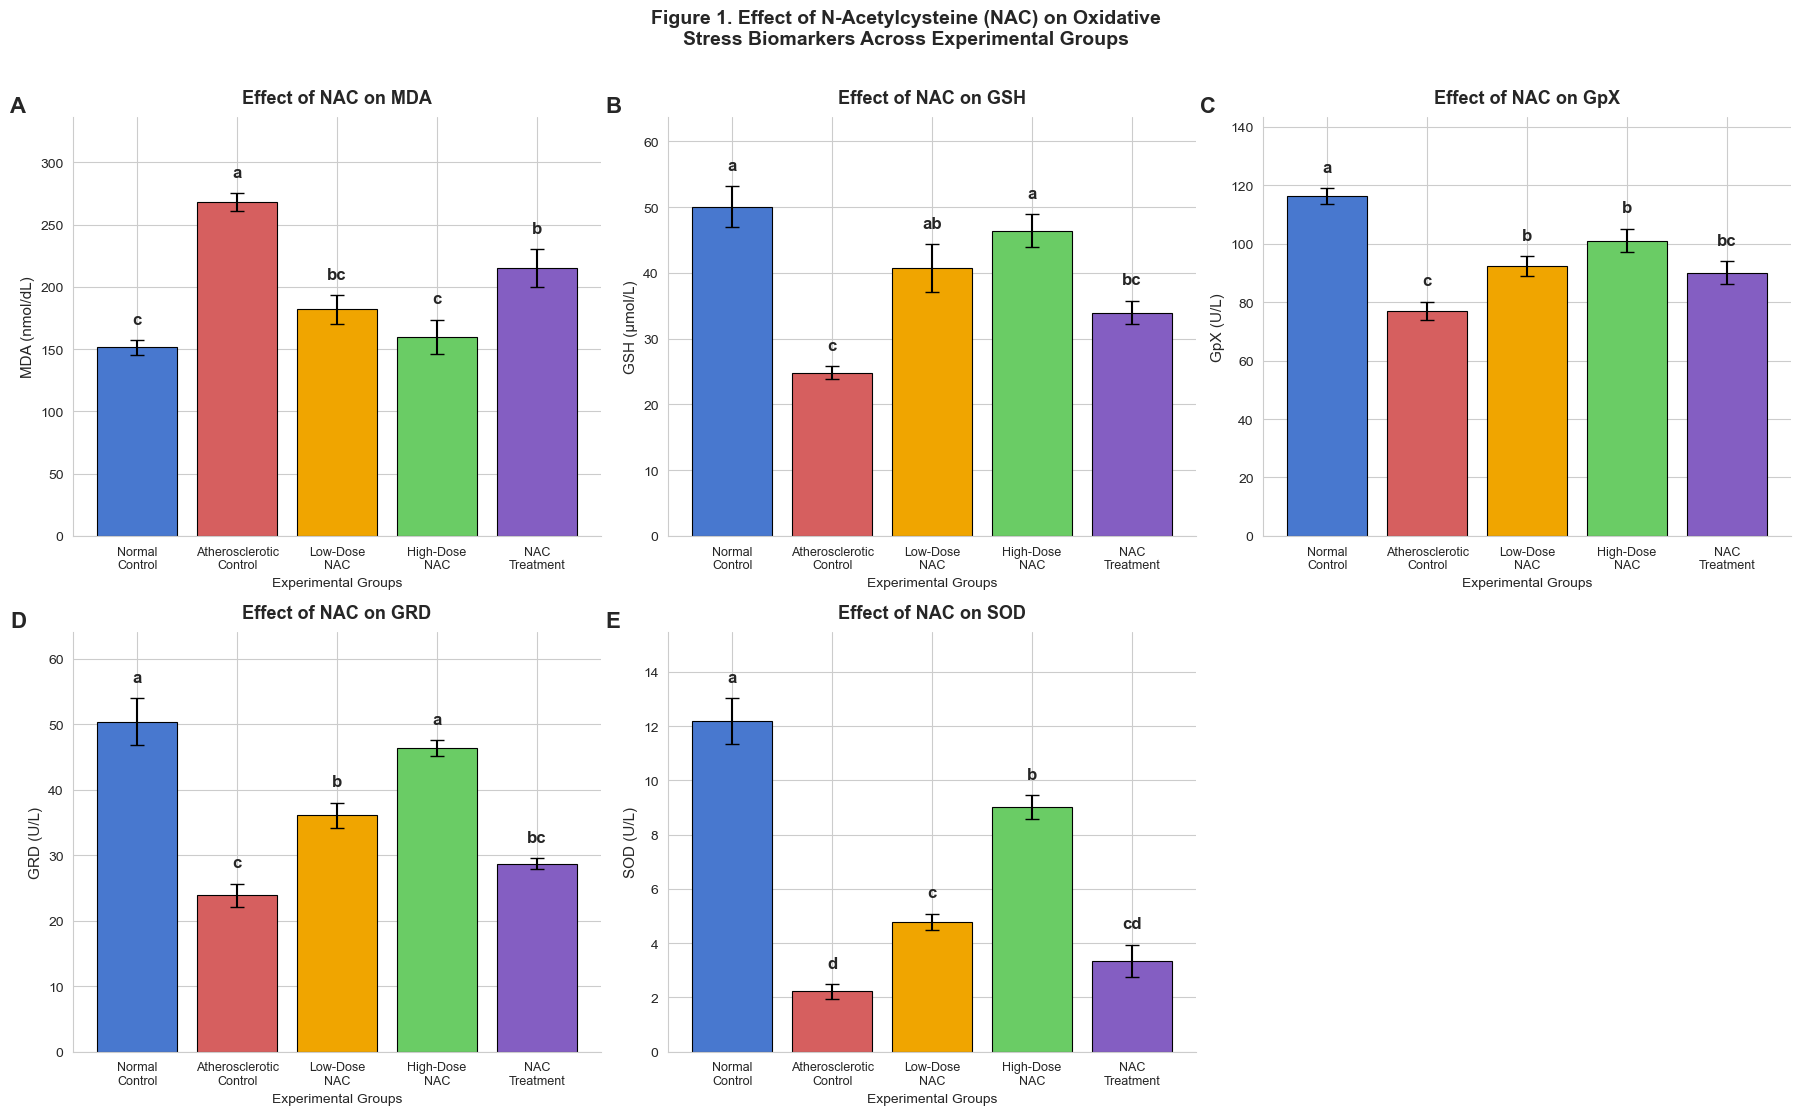

✅ Figure 1 saved


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, marker in enumerate(markers):
    ax    = axes[idx]
    means = df.groupby("Group", sort=False)[marker]\
               .mean().reindex(group_order)
    sems  = df.groupby("Group", sort=False)[marker]\
               .sem().reindex(group_order)
    letts = all_letters[marker]

    ax.bar(range(len(group_order)), means,
           yerr=sems, capsize=5,
           color=colors, edgecolor="black", linewidth=0.8,
           error_kw={"elinewidth":1.5,"ecolor":"black"})

    for i, (m, s, g) in enumerate(zip(means, sems, group_order)):
        ax.text(i, m + s + means.max()*0.04,
                letts[g], ha="center", va="bottom",
                fontsize=12, fontweight="bold")

    ax.set_title(f"Effect of NAC on {marker}",
                 fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel(f"{marker} ({units[marker]})", fontsize=11)
    ax.set_xticks(range(len(group_order)))
    ax.set_xticklabels(["Normal\nControl","Atherosclerotic\nControl",
                         "Low-Dose\nNAC","High-Dose\nNAC",
                         "NAC\nTreatment"], fontsize=9)
    ax.set_xlabel("Experimental Groups", fontsize=10)
    ax.text(-0.12, 1.05, panel_labels[idx],
            transform=ax.transAxes,
            fontsize=16, fontweight="bold", va="top")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(0, means.max() + sems.max() + means.max()*0.2)

axes[5].set_visible(False)
plt.suptitle(
    "Figure 1. Effect of N-Acetylcysteine (NAC) on Oxidative\n"
    "Stress Biomarkers Across Experimental Groups",
    fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../figures/Figure1_barcharts.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 1 saved")

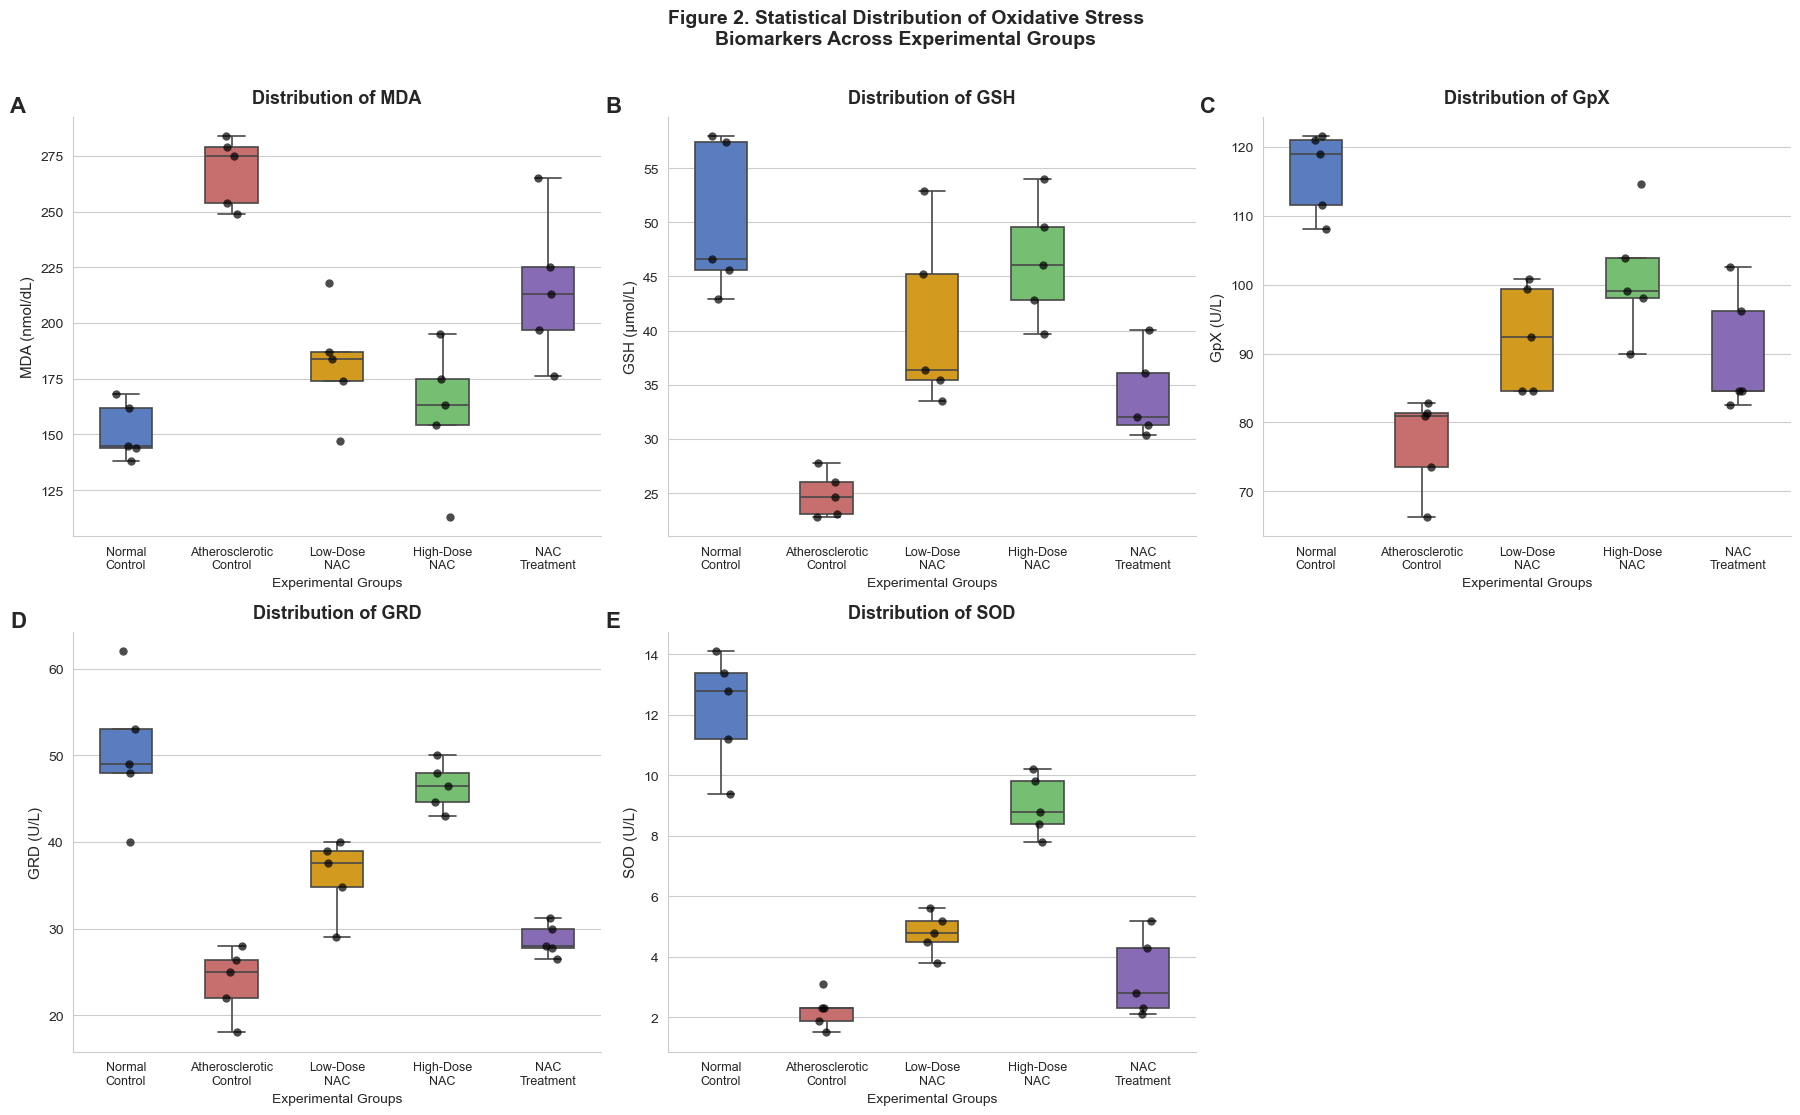

✅ Figure 2 saved


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, marker in enumerate(markers):
    ax = axes[idx]

    sns.boxplot(data=df, x="Group", y=marker,
                order=group_order, palette=palette,
                width=0.5, linewidth=1.2,
                fliersize=0, ax=ax)

    sns.stripplot(data=df, x="Group", y=marker,
                  order=group_order, color="black",
                  size=6, alpha=0.7, jitter=True, ax=ax)

    ax.set_title(f"Distribution of {marker}",
                 fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel(f"{marker} ({units[marker]})", fontsize=11)
    ax.set_xlabel("Experimental Groups", fontsize=10)
    ax.set_xticklabels(["Normal\nControl","Atherosclerotic\nControl",
                         "Low-Dose\nNAC","High-Dose\nNAC",
                         "NAC\nTreatment"], fontsize=9)
    ax.text(-0.12, 1.05, panel_labels[idx],
            transform=ax.transAxes,
            fontsize=16, fontweight="bold", va="top")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[5].set_visible(False)
plt.suptitle(
    "Figure 2. Statistical Distribution of Oxidative Stress\n"
    "Biomarkers Across Experimental Groups",
    fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../figures/Figure2_boxplots.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 2 saved")

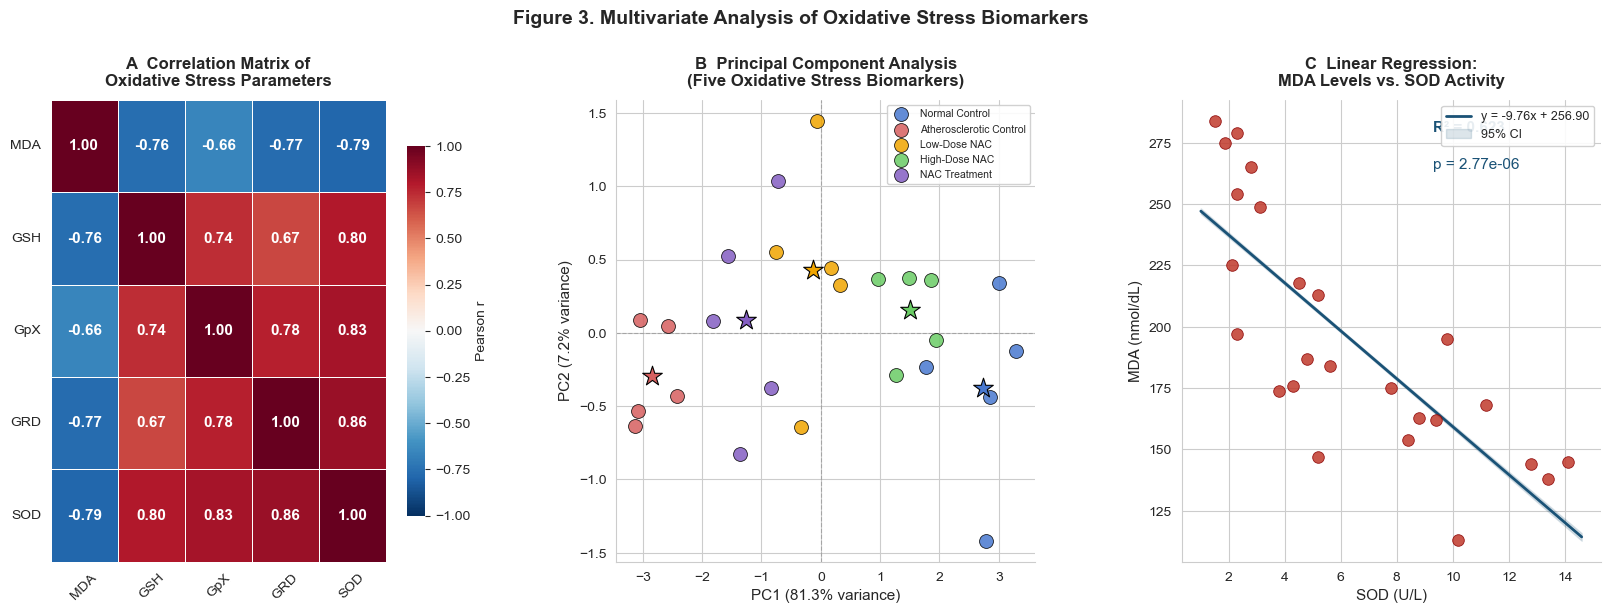

✅ Figure 3 saved
   PC1=81.3%  PC2=7.2%  Total=88.6%
   R²=0.623  slope=-9.764  p=2.77e-06


In [4]:
fig = plt.figure(figsize=(20, 6))
gs  = fig.add_gridspec(1, 3, wspace=0.35)

# ── Panel A: Correlation Heatmap ──────────────────────────────
ax1 = fig.add_subplot(gs[0])
corr = df[markers].corr(method="pearson").round(2)

sns.heatmap(corr, ax=ax1,
            annot=True, fmt=".2f",
            annot_kws={"size":11,"weight":"bold"},
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white",
            cbar_kws={"shrink":0.8,"label":"Pearson r"})

ax1.set_title("A  Correlation Matrix of\nOxidative Stress Parameters",
              fontsize=12, fontweight="bold", pad=10)
ax1.tick_params(axis="x", rotation=45)
ax1.tick_params(axis="y", rotation=0)

# ── Panel B: PCA Score Plot ────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
X_scaled = StandardScaler().fit_transform(df[markers])
pca      = PCA(n_components=2)
scores   = pca.fit_transform(X_scaled)
var_exp  = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame({
    "PC1": scores[:,0],
    "PC2": scores[:,1],
    "Group": df["Group"].values
})

for i, g in enumerate(group_order):
    sub = pca_df[pca_df["Group"] == g]
    ax2.scatter(sub["PC1"], sub["PC2"],
                color=colors[i], label=g,
                s=100, edgecolor="black",
                linewidth=0.6, zorder=3, alpha=0.85)
    ax2.scatter(sub["PC1"].mean(), sub["PC2"].mean(),
                color=colors[i], s=220, marker="*",
                edgecolor="black", linewidth=0.8, zorder=4)

ax2.set_xlabel(f"PC1 ({var_exp[0]:.1f}% variance)", fontsize=11)
ax2.set_ylabel(f"PC2 ({var_exp[1]:.1f}% variance)", fontsize=11)
ax2.set_title("B  Principal Component Analysis\n"
              "(Five Oxidative Stress Biomarkers)",
              fontsize=12, fontweight="bold", pad=10)
ax2.legend(fontsize=7.5, loc="best", framealpha=0.9)
ax2.axhline(0, color="gray", lw=0.8, ls="--", alpha=0.5)
ax2.axvline(0, color="gray", lw=0.8, ls="--", alpha=0.5)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# ── Panel C: Linear Regression MDA vs SOD ────────────────────
ax3 = fig.add_subplot(gs[2])
x = df["SOD"].values
y = df["MDA"].values
slope, intercept, r_val, p_val, se = stats.linregress(x, y)
r2 = r_val**2

x_line  = np.linspace(x.min()-0.5, x.max()+0.5, 200)
y_line  = slope * x_line + intercept
n       = len(x)
x_mean  = x.mean()
se_line = se * np.sqrt(1/n + (x_line-x_mean)**2 /
                        np.sum((x-x_mean)**2))
t_crit  = stats.t.ppf(0.975, df=n-2)

ax3.scatter(x, y, color="#C0392B", s=70,
            edgecolor="darkred", lw=0.6,
            zorder=3, alpha=0.85)
ax3.plot(x_line, y_line, color="#1A5276", lw=2,
         label=f"y = {slope:.2f}x + {intercept:.2f}")
ax3.fill_between(x_line,
                  y_line - t_crit*se_line,
                  y_line + t_crit*se_line,
                  alpha=0.15, color="#1A5276",
                  label="95% CI")

ax3.set_xlabel("SOD (U/L)", fontsize=11)
ax3.set_ylabel("MDA (nmol/dL)", fontsize=11)
ax3.set_title("C  Linear Regression:\nMDA Levels vs. SOD Activity",
              fontsize=12, fontweight="bold", pad=10)
ax3.text(0.60, 0.93, f"R² = {r2:.3f}",
         transform=ax3.transAxes,
         fontsize=11, fontweight="bold", color="#1A5276")
ax3.text(0.60, 0.85, f"p = {p_val:.2e}",
         transform=ax3.transAxes,
         fontsize=11, color="#1A5276")
ax3.legend(fontsize=9, framealpha=0.9)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

plt.suptitle(
    "Figure 3. Multivariate Analysis of Oxidative Stress Biomarkers",
    fontsize=14, fontweight="bold", y=1.03)
plt.savefig("../figures/Figure3_corr_pca_regression.png",
            dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Figure 3 saved")
print(f"   PC1={var_exp[0]:.1f}%  PC2={var_exp[1]:.1f}%  "
      f"Total={sum(var_exp):.1f}%")
print(f"   R²={r2:.3f}  slope={slope:.3f}  p={p_val:.2e}")

In [5]:
readme = """# Oxidative Stress Biomarker Analysis in Atherosclerosis
### Python-based Statistical & Multivariate Analysis Pipeline

[![Python](https://img.shields.io/badge/Python-3.10-blue?logo=python)](https://python.org)
[![Jupyter](https://img.shields.io/badge/Jupyter-Lab-orange?logo=jupyter)](https://jupyter.org)
[![License: MIT](https://img.shields.io/badge/License-MIT-green)](LICENSE)

## Overview
Complete statistical analysis pipeline for a master's thesis investigating 
the **protective and therapeutic effects of N-Acetylcysteine (NAC)** against 
vitamin D3/high-fat-diet-induced atherosclerosis in Sprague-Dawley rats.

> Manuscript under review — *Pharmacological Research* (IF 7.0)

## Biomarkers
| Marker | Full Name | Role |
|---|---|---|
| MDA | Malondialdehyde | Lipid peroxidation index |
| GSH | Reduced Glutathione | Non-enzymatic antioxidant |
| GpX | Glutathione Peroxidase | Peroxide scavenging |
| GRD | Glutathione Reductase | GSH recycling |
| SOD | Superoxide Dismutase | Primary ROS defence |

## Experimental Groups
| Group | Treatment |
|---|---|
| Normal Control | Standard diet + saline |
| Atherosclerotic Control | HFHC diet + Vitamin D3 |
| Low-Dose NAC | HFHC + 150 mg/kg/day NAC (prophylactic) |
| High-Dose NAC | HFHC + 300 mg/kg/day NAC (prophylactic) |
| NAC Treatment | HFHC + 300 mg/kg/day NAC (therapeutic) |

## Notebooks
| Notebook | Contents |
|---|---|
| 01_data_cleaning.ipynb | Raw Excel → clean CSV |
| 02_statistical_analysis.ipynb | Shapiro-Wilk, Levene, ANOVA, Tukey HSD, CLD |
| 03_visualisation.ipynb | Bar charts, Boxplots, Heatmap, PCA, Regression |

## Key Findings
- Atherogenic induction raised MDA by **~77%** and depleted SOD by **~82%**
- High-Dose NAC normalised GSH, GRD, and MDA to normal control levels
- PCA: PC1 captures **>80% of total variance** across all five biomarkers
- SOD predicts serum MDA concentration (R² > 0.60, p < 0.001)

## Tech Stack
`Python 3.10` · `Jupyter Lab` · `pandas` · `NumPy` · `SciPy` · 
`statsmodels` · `scikit-learn` · `Matplotlib` · `Seaborn` · `NetworkX`

## Author
**Abdulmuhsen Almutairi**  
MSc Biochemistry — University of Jeddah, Saudi Arabia  
📧 m7sen.1223@gmail.com
"""

with open("../README.md", "w", encoding="utf-8") as f:
    f.write(readme)
print("✅ README.md saved to project root")

✅ README.md saved to project root
